In [100]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

In [101]:
df = pd.read_csv('/Users/mahdeeahmed/Documents/Oasis Infobyte/AB_NYC_2019.csv')
df['last_review']=pd.to_datetime(df['last_review'])
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaT,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaT,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaT,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaT,NaN,6,2


### Exploratory data analysis

In [102]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.373221,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

In [104]:
df.nunique()

id                                48895
name                              47905
host_id                           37457
host_name                         11452
neighbourhood_group                   5
neighbourhood                       221
latitude                          19048
longitude                         14718
room_type                             3
price                               674
minimum_nights                      109
number_of_reviews                   394
last_review                        1764
reviews_per_month                   937
calculated_host_listings_count       47
availability_365                    366
dtype: int64

In [105]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### Visualizing missing values with heatmap

<Axes: >

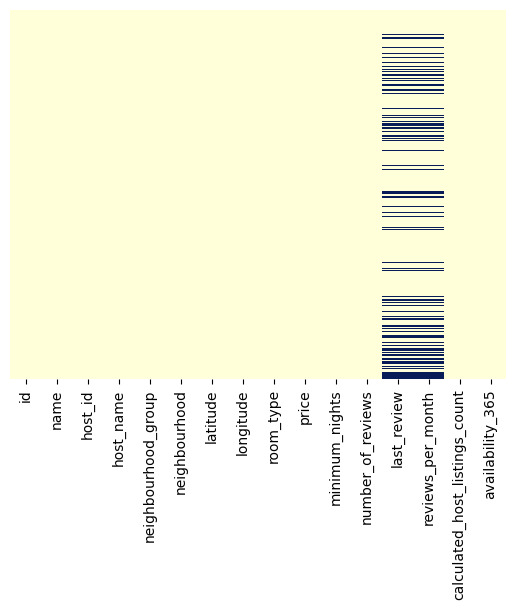

In [106]:
sns.heatmap(df.isnull(),cbar = False,yticklabels=False,cmap='YlGnBu')

### Dropping the null values in name and host_name. Filling up up the reviews_per_month column with 0

In [107]:
df.dropna(subset=['name','host_name'],inplace=True)

In [108]:
df['reviews_per_month'].fillna(0,inplace=True)

/var/folders/cx/tfcg_b5d0sd02g3ng3fjf7xh0000gn/T/ipykernel_11004/775648051.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0,inplace=True)


### Converting the null values in last review column with 0 and 1  

In [109]:
# df['reviewed'] = df['last_review'].notna()
def reviewed(data): 
    if pd.notna(data):
        return 1
    else: 
        return 0

df['has_review'] = df['last_review'].apply(reviewed)

### Grouping data for outlier detection

In [110]:
hst_cnt = df.groupby('host_name')['calculated_host_listings_count'].sum().reset_index().sort_values('calculated_host_listings_count',ascending=False)
most_host_count = hst_cnt.set_index('host_name')
most_host_count

,calculated_host_listings_count
host_name,
Sonder (NYC),106929
Blueground,53824
Kara,14679
Kazuya,10609
Sonder,9216
...,...
Jeremie,1
Jerbean,1
Jerald,1


In [111]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'has_review'],
      dtype='object')

### Outlier Detection

In [121]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_review,price z-score,min night z-score
count,4.885800e+04,4.885800e+04,48858.000000,48858.000000,48858.000000,48858.000000,48858.000000,38821,48858.000000,48858.000000,48858.000000,48858.000000,4.885800e+04,4.885800e+04
mean,1.902335e+07,6.763169e+07,40.728941,-73.952170,152.740309,7.012444,23.273098,2018-10-04 07:23:47.072976128,1.091124,7.148369,112.801425,0.794568,-6.980648e-18,-2.414141e-17
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000,0.000000,-6.358023e-01,-3.003255e-01
25%,9.475980e+06,7.818669e+06,40.690090,-73.983070,69.000000,1.000000,1.000000,2018-07-09 00:00:00,0.040000,1.000000,0.000000,1.000000,-3.485804e-01,-3.003255e-01
50%,1.969114e+07,3.079133e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.370000,1.000000,45.000000,1.000000,-1.945629e-01,-2.004242e-01
75%,2.915765e+07,1.074344e+08,40.763107,-73.936280,175.000000,5.000000,24.000000,2019-06-23 00:00:00,1.580000,2.000000,227.000000,1.000000,9.265899e-02,-1.005229e-01
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000,1.000000,4.099056e+01,6.208804e+01
std,1.098289e+07,7.862389e+07,0.054528,0.046159,240.232386,20.019757,44.549898,NaN,1.597270,32.964600,131.610962,0.404021,1.000000e+00,1.000000e+00


<Axes: xlabel='price', ylabel='Count'>

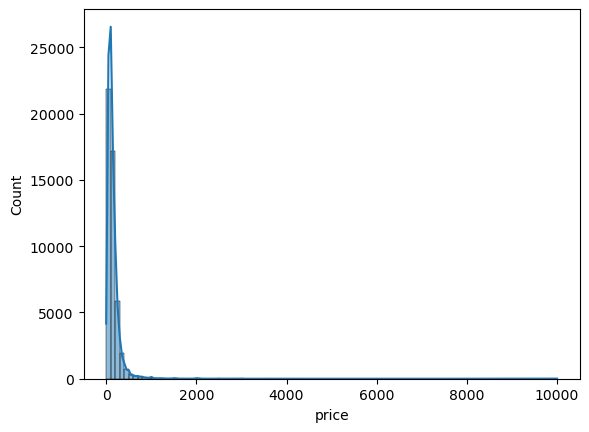

In [122]:
sns.histplot(df['price'],bins=100,kde=True,fill=True)

<Axes: xlabel='number_of_reviews', ylabel='price'>

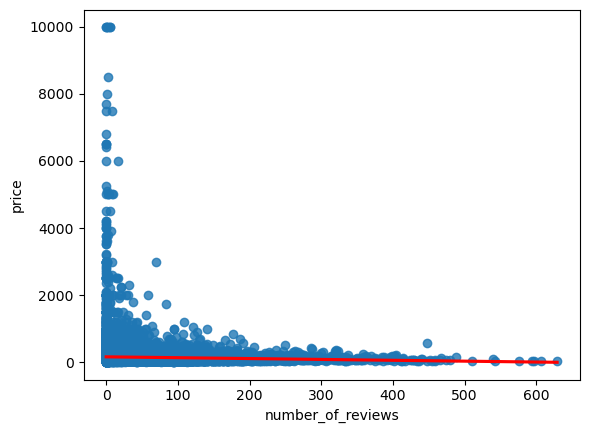

In [112]:
sns.regplot(df,x='number_of_reviews',y='price',line_kws={'color':'red'})
#Basically theres not obvious relation between price and number of reviews

# Outlier detection for price and minimum nights and eliminating them 

In [113]:
# upper_price = df['price'].mean()+ 3*df['price'].std()
# lower_price = 0

# print(f"'Upper Limit :'{upper_price}")
# print(f"'Lower Limit :'{lower_price}")
# new_df = df[df['price']< upper_price]
# sns.boxplot(new_df['price'])

In [120]:
df['price z-score'] = (df['price']-df['price'].mean())/df['price'].std()
df['min night z-score'] = (df['minimum_nights']-df['minimum_nights'].mean())/df['minimum_nights'].std()


new_df= df[(df['price z-score']< 2) & (df['price z-score']> -2) &

        (df['min night z-score']< 2) & (df['min night z-score']> -2) ]


new_df[['price','minimum_nights']].describe()

,price,minimum_nights
count,47648.000000,47648.000000
mean,134.105398,5.728719
std,94.015179,8.440405
min,0.000000,1.000000
25%,69.000000,1.000000
50%,103.000000,2.000000
75%,175.000000,5.000000
max,625.000000,47.000000


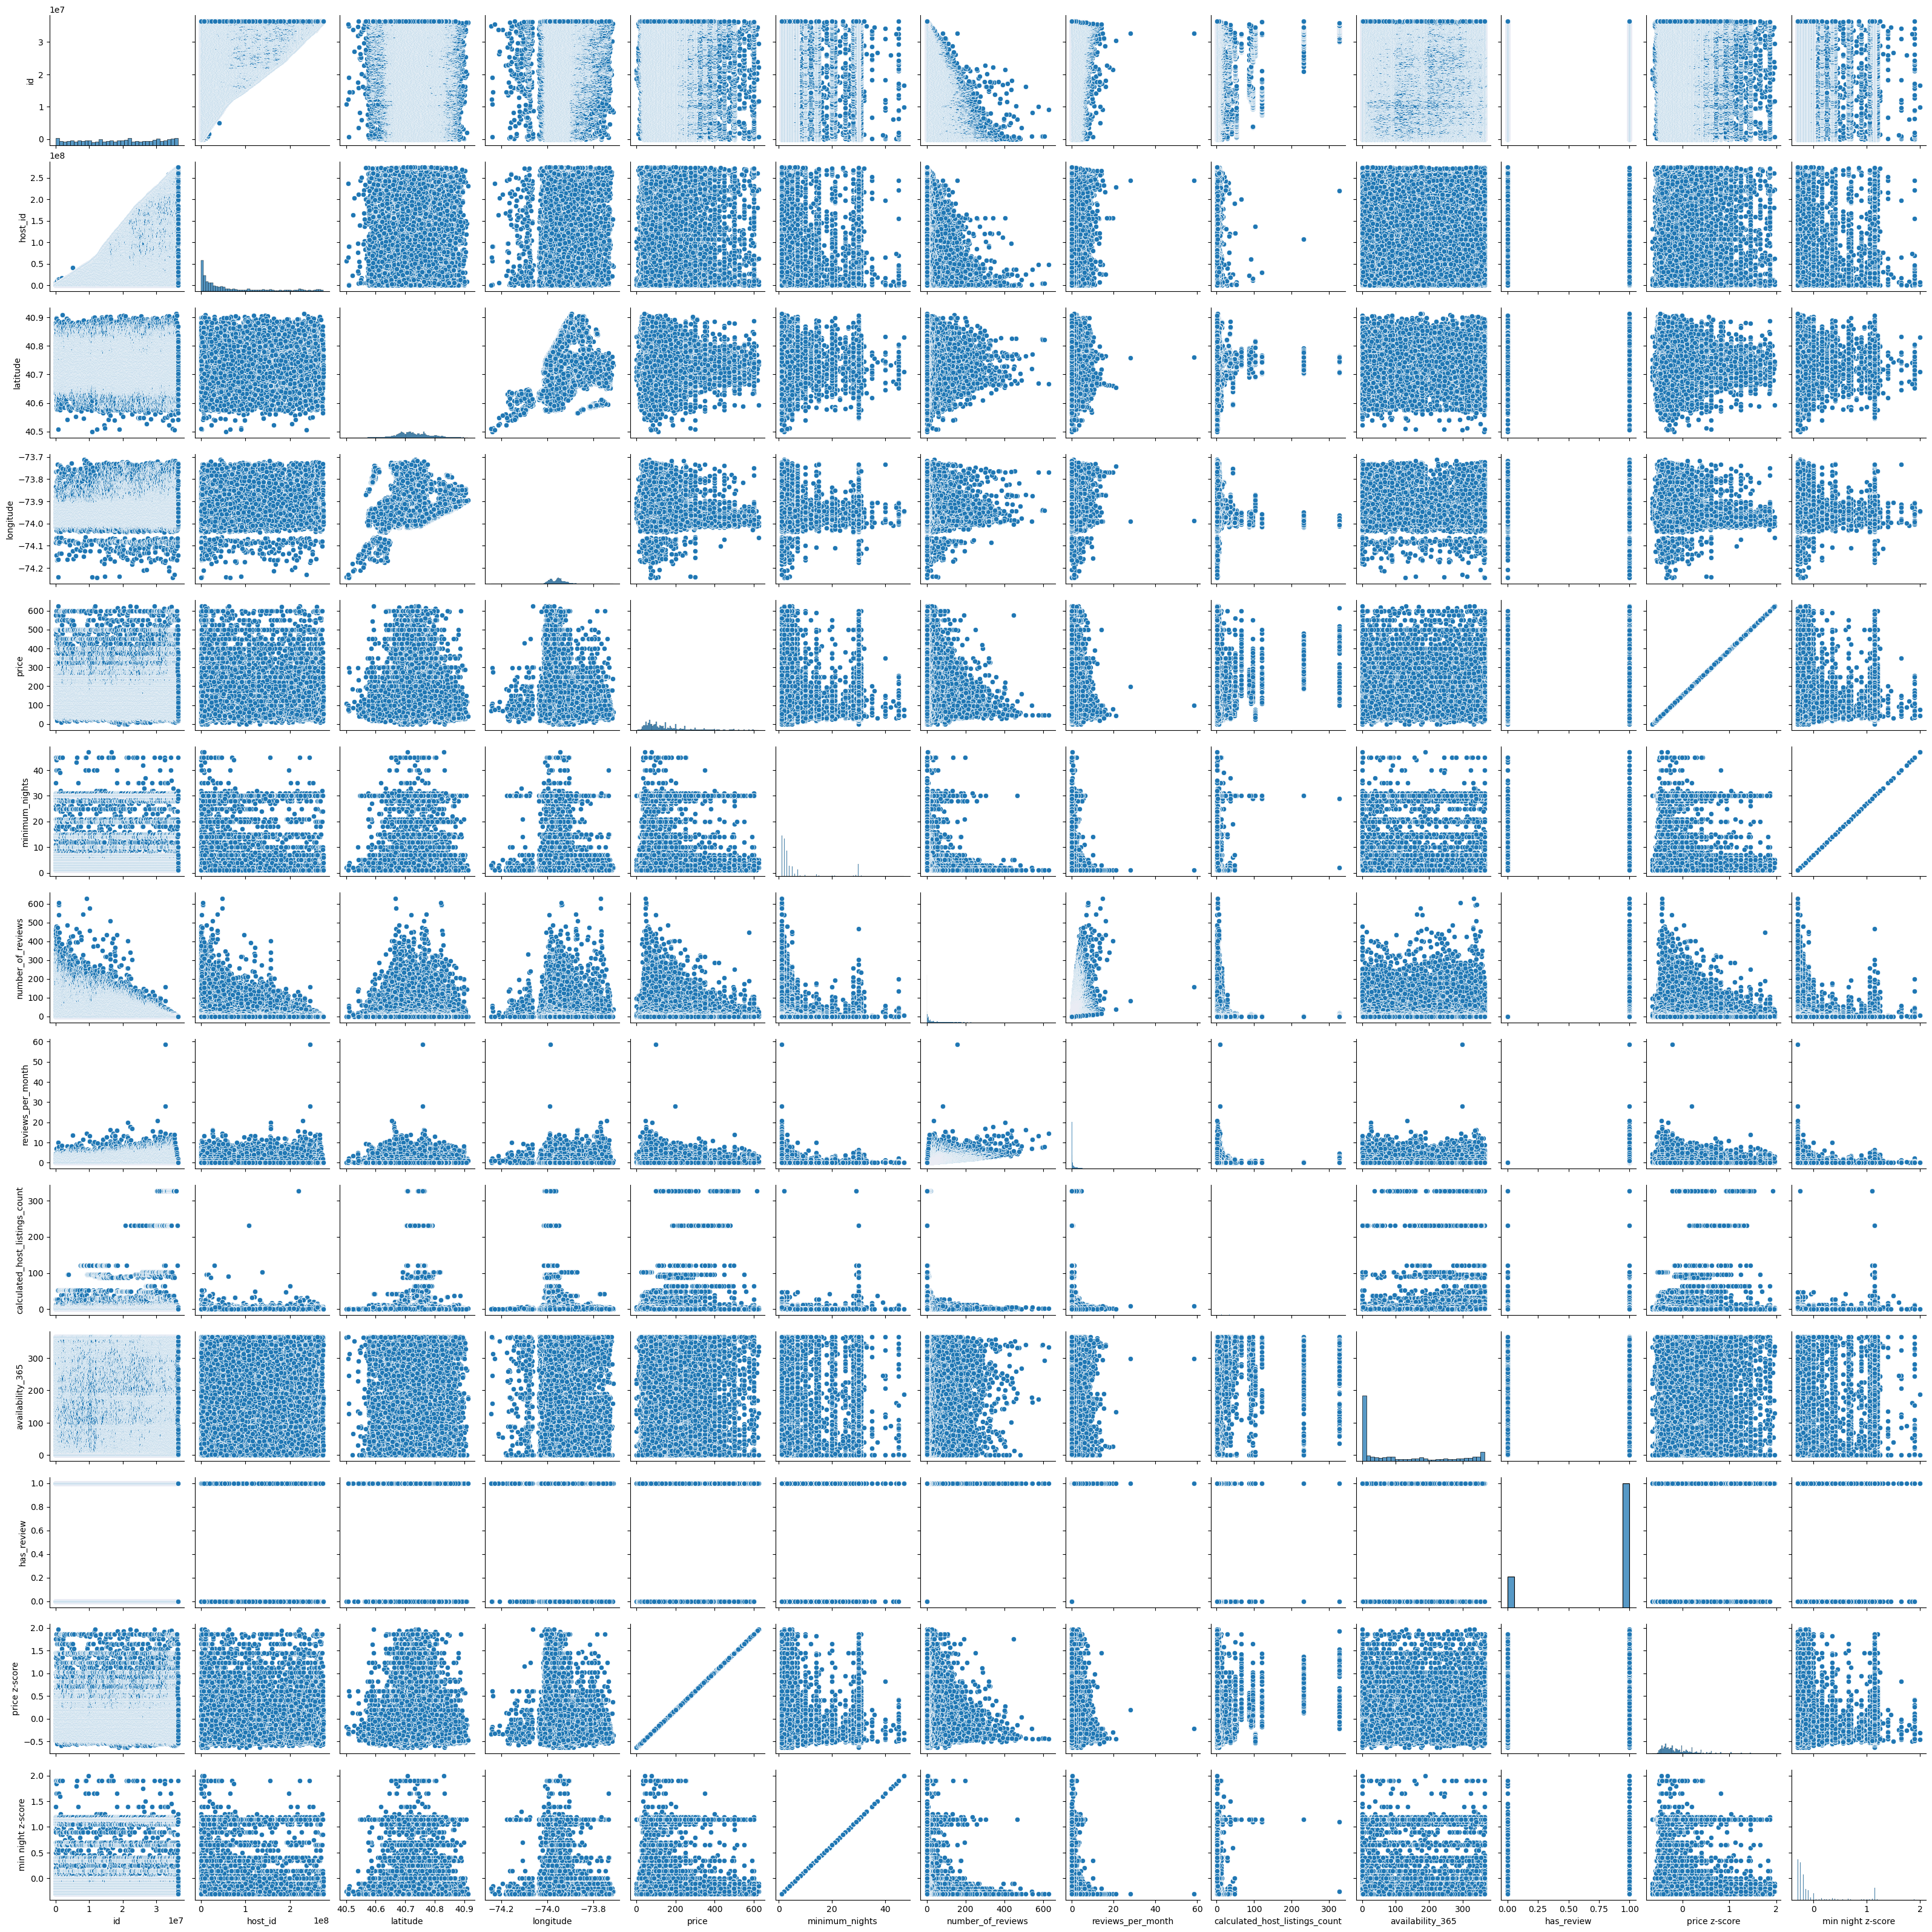

In [124]:
sns.pairplot(new_df)
#now we 